# PolypVision AI — Exploratory Kvasir-SEG Baseline

Cleaned research notebook derived from the original Colab experiment. Streamlit/server-debugging cells and known erroneous standalone augmentation cells were removed. Results remain exploratory; see the repository README for evaluation caveats.


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not connected")

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


## 1. Dataset integrity


In [ ]:
import os
import numpy as np
from PIL import Image

DATASET_PATH = '/content/drive/MyDrive/Kvasir-SEG'

IMAGE_DIR = os.path.join(DATASET_PATH, 'images')
MASK_DIR = os.path.join(DATASET_PATH, 'masks')

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

mask_files = sorted([
    f for f in os.listdir(MASK_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
])

print("Images:", len(image_files))
print("Masks:", len(mask_files))

Images: 1012
Masks: 1012


In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image

image_stems = {Path(f).stem for f in image_files}
mask_stems = {Path(f).stem for f in mask_files}

print("Images without matching masks:", len(image_stems - mask_stems))
print("Masks without matching images:", len(mask_stems - image_stems))

print("\nSample image:", image_files[0])
print("Sample mask:", mask_files[0])

sample_mask = np.array(
    Image.open(os.path.join(MASK_DIR, mask_files[0]))
)

print("\nMask shape:", sample_mask.shape)
print("Mask dtype:", sample_mask.dtype)
print("Mask minimum:", sample_mask.min())
print("Mask maximum:", sample_mask.max())
print("Unique pixel values:", np.unique(sample_mask)[:20])
print("Number of unique values:", len(np.unique(sample_mask)))

Images without matching masks: 12
Masks without matching images: 12

Sample image: cju0qkwl35piu0993l0dewei2.jpg
Sample mask: cju0qkwl35piu0993l0dewei2.jpg

Mask shape: (529, 622, 3)
Mask dtype: uint8
Mask minimum: 0
Mask maximum: 255
Unique pixel values: [  0   1   2   3   4   5   6   7   8 247 248 249 250 251 252 253 254 255]
Number of unique values: 18


In [ ]:
from pathlib import Path

unmatched_images = sorted(image_stems - mask_stems)
unmatched_masks = sorted(mask_stems - image_stems)

print("UNMATCHED IMAGES:")
for f in unmatched_images:
    print(f)

print("\nUNMATCHED MASKS:")
for f in unmatched_masks:
    print(f)

UNMATCHED IMAGES:
cju13fwthn9mq0835gacxgy01 (1)
cju2p4ddkmzxj0993p94o62av (1)
cju2xjz2ju8pe0993ysv9wg17 (1)
cju2zpw4q9vzr0801p0lysjdl (1)
cju30gxjq0djk0988jytm49rs (1)
cju33eqwbcch208012jikwdky (1)
cju43eigtm6ev0801mv0m96t1 (1)
cju5fs6j6d8350801vglraq4u (1)
cju5von04litr08718j8po40a (1)
cju7dhpsc2dnn0818025m6857 (1)
cju8ando2qqdo0818ck7i1be1 (1)
cjyzlw7f9faqr070129au64sq (1)

UNMATCHED MASKS:
cju16whaj0e7n0855q7b6cjkm (1)
cju1871y11d6r0799k6cw4yze (1)
cju1fmsyf6gxb0801cimx2gle (1)
cju2hewssldzx0835ep795xu0 (1)
cju2phaksnahz0993yxogjcpv (1)
cju3uhb79gcgr0871orbrbi3x (1)
cju3y0pjrj1c30755nxekxccj (1)
cju5yimthmlv80850zhoc90c2 (1)
cju6w733bveoz0817e600tw72 (1)
cju6z2616wqbk07555bvnuyr1 (1)
cju77vvcwzcm50850lzoykuva (1)
cju7f6cqy2ur20818t1saazbm (1)


In [ ]:
from pathlib import Path

def check_suffix(files, own_files, opposite_files, label):
    own_stems = {Path(f).stem for f in own_files}
    opposite_stems = {Path(f).stem for f in opposite_files}

    print(f"\n--- {label} ---")

    for stem in files:
        base = stem.removesuffix(" (1)")

        print(
            f"{stem}\n"
            f"  Original exists in same folder: {base in own_stems}\n"
            f"  Original exists in opposite folder: {base in opposite_stems}"
        )

check_suffix(
    unmatched_images,
    image_files,
    mask_files,
    "UNMATCHED IMAGES"
)

check_suffix(
    unmatched_masks,
    mask_files,
    image_files,
    "UNMATCHED MASKS"
)


--- UNMATCHED IMAGES ---
cju13fwthn9mq0835gacxgy01 (1)
  Original exists in same folder: True
  Original exists in opposite folder: True
cju2p4ddkmzxj0993p94o62av (1)
  Original exists in same folder: True
  Original exists in opposite folder: True
cju2xjz2ju8pe0993ysv9wg17 (1)
  Original exists in same folder: True
  Original exists in opposite folder: True
cju2zpw4q9vzr0801p0lysjdl (1)
  Original exists in same folder: True
  Original exists in opposite folder: True
cju30gxjq0djk0988jytm49rs (1)
  Original exists in same folder: True
  Original exists in opposite folder: True
cju33eqwbcch208012jikwdky (1)
  Original exists in same folder: True
  Original exists in opposite folder: True
cju43eigtm6ev0801mv0m96t1 (1)
  Original exists in same folder: True
  Original exists in opposite folder: True
cju5fs6j6d8350801vglraq4u (1)
  Original exists in same folder: True
  Original exists in opposite folder: True
cju5von04litr08718j8po40a (1)
  Original exists in same folder: True
  Origina

In [ ]:
from pathlib import Path
import os
import hashlib

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

for stem in unmatched_images:
    base = stem.removesuffix(" (1)")

    original_image = os.path.join(IMAGE_DIR, base + ".jpg")
    duplicate_image = os.path.join(IMAGE_DIR, stem + ".jpg")

    original_mask = os.path.join(MASK_DIR, base + ".jpg")
    duplicate_mask = os.path.join(MASK_DIR, stem + ".jpg")

    print(f"\n{base}")
    print("Original image exists:", os.path.exists(original_image))
    print("Duplicate image exists:", os.path.exists(duplicate_image))
    print("Original mask exists:", os.path.exists(original_mask))
    print("Duplicate mask exists:", os.path.exists(duplicate_mask))

    if all(map(os.path.exists, [
        original_image, duplicate_image,
        original_mask, duplicate_mask
    ])):
        print("Images identical:", sha256(original_image) == sha256(duplicate_image))
        print("Masks identical:", sha256(original_mask) == sha256(duplicate_mask))


cju13fwthn9mq0835gacxgy01
Original image exists: True
Duplicate image exists: True
Original mask exists: True
Duplicate mask exists: False

cju2p4ddkmzxj0993p94o62av
Original image exists: True
Duplicate image exists: True
Original mask exists: True
Duplicate mask exists: False

cju2xjz2ju8pe0993ysv9wg17
Original image exists: True
Duplicate image exists: True
Original mask exists: True
Duplicate mask exists: False

cju2zpw4q9vzr0801p0lysjdl
Original image exists: True
Duplicate image exists: True
Original mask exists: True
Duplicate mask exists: False

cju30gxjq0djk0988jytm49rs
Original image exists: True
Duplicate image exists: True
Original mask exists: True
Duplicate mask exists: False

cju33eqwbcch208012jikwdky
Original image exists: True
Duplicate image exists: True
Original mask exists: True
Duplicate mask exists: False

cju43eigtm6ev0801mv0m96t1
Original image exists: True
Duplicate image exists: True
Original mask exists: True
Duplicate mask exists: False

cju5fs6j6d8350801vg

In [ ]:
from pathlib import Path
import os

image_map = {
    Path(f).stem: os.path.join(IMAGE_DIR, f)
    for f in image_files
}

mask_map = {
    Path(f).stem: os.path.join(MASK_DIR, f)
    for f in mask_files
}

# Exclude suffixed copies from pairing
image_map = {
    stem: path
    for stem, path in image_map.items()
    if not stem.endswith(" (1)")
}

mask_map = {
    stem: path
    for stem, path in mask_map.items()
    if not stem.endswith(" (1)")
}

valid_ids = sorted(set(image_map) & set(mask_map))

missing_images = sorted(set(mask_map) - set(image_map))
missing_masks = sorted(set(image_map) - set(mask_map))

print("Valid pairs:", len(valid_ids))
print("Missing images:", len(missing_images))
print("Missing masks:", len(missing_masks))

print("\nFirst 5 valid pairs:")
for sample_id in valid_ids[:5]:
    print(
        sample_id,
        "->",
        os.path.basename(image_map[sample_id]),
        "|",
        os.path.basename(mask_map[sample_id])
    )

Valid pairs: 1000
Missing images: 0
Missing masks: 0

First 5 valid pairs:
cju0qkwl35piu0993l0dewei2 -> cju0qkwl35piu0993l0dewei2.jpg | cju0qkwl35piu0993l0dewei2.jpg
cju0qoxqj9q6s0835b43399p4 -> cju0qoxqj9q6s0835b43399p4.jpg | cju0qoxqj9q6s0835b43399p4.jpg
cju0qx73cjw570799j4n5cjze -> cju0qx73cjw570799j4n5cjze.jpg | cju0qx73cjw570799j4n5cjze.jpg
cju0roawvklrq0799vmjorwfv -> cju0roawvklrq0799vmjorwfv.jpg | cju0roawvklrq0799vmjorwfv.jpg
cju0rx1idathl0835detmsp84 -> cju0rx1idathl0835detmsp84.jpg | cju0rx1idathl0835detmsp84.jpg


## 2. Mask inspection and preprocessing


In [ ]:
import numpy as np
from PIL import Image
import os

sample_id = valid_ids[0]

image = np.array(Image.open(image_map[sample_id]).convert("RGB"))
mask = np.array(Image.open(mask_map[sample_id]).convert("RGB"))

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)

print("\nChannel equality:")
print("R == G:", np.array_equal(mask[:,:,0], mask[:,:,1]))
print("G == B:", np.array_equal(mask[:,:,1], mask[:,:,2]))

gray_mask = np.array(Image.open(mask_map[sample_id]).convert("L"))

print("\nGrayscale mask:")
print("Minimum:", gray_mask.min())
print("Maximum:", gray_mask.max())
print("Unique values:", np.unique(gray_mask)[:30])

binary_mask = (gray_mask > 127).astype(np.uint8)

print("\nForeground pixels:", binary_mask.sum())
print("Background pixels:", binary_mask.size - binary_mask.sum())
print("Foreground percentage:", round(binary_mask.mean() * 100, 2), "%")

Image shape: (529, 622, 3)
Mask shape: (529, 622, 3)

Channel equality:
R == G: True
G == B: True

Grayscale mask:
Minimum: 0
Maximum: 255
Unique values: [  0   1   2   3   4   5   6   7   8 247 248 249 250 251 252 253 254 255]

Foreground pixels: 93043
Background pixels: 235995
Foreground percentage: 28.28 %


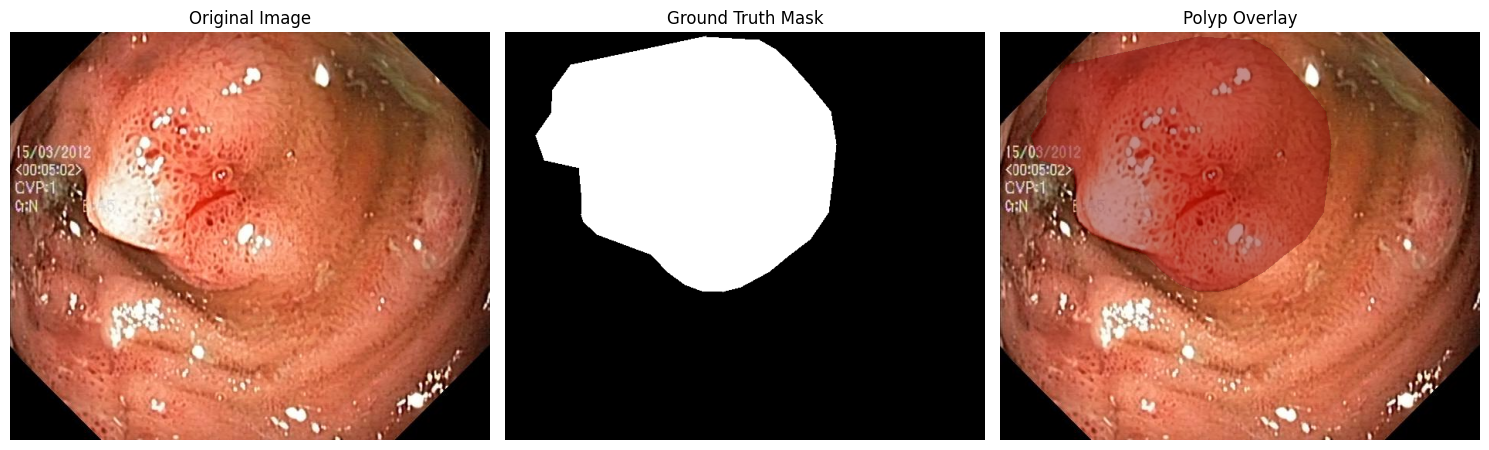

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

binary_mask = (gray_mask > 127).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original Image")

axes[1].imshow(binary_mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Ground Truth Mask")

axes[2].imshow(image)
axes[2].imshow(
    np.ma.masked_where(binary_mask == 0, binary_mask),
    cmap="jet",
    alpha=0.45,
    vmin=0,
    vmax=1
)
axes[2].set_title("Polyp Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Reproducible split


In [ ]:
import numpy as np

SEED = 42
rng = np.random.default_rng(SEED)

indices = rng.permutation(len(valid_ids))

train_indices = indices[:700]
val_indices = indices[700:850]
test_indices = indices[850:]

print("Training:", len(train_indices))
print("Validation:", len(val_indices))
print("Testing:", len(test_indices))

print("\nRandom seed:", SEED)

Training: 700
Validation: 150
Testing: 150

Random seed: 42


## 4. Dataset and loaders


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

IMAGE_SIZE = 256

class PolypDataset(Dataset):
    def __init__(self, indices):
        self.ids = [valid_ids[i] for i in indices]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sample_id = self.ids[idx]

        # Load RGB image
        image = Image.open(image_map[sample_id]).convert("RGB")

        # Load grayscale mask
        mask = Image.open(mask_map[sample_id]).convert("L")

        # Resize image and mask using appropriate interpolation
        image = image.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.BILINEAR
        )

        mask = mask.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.NEAREST
        )

        # Convert image to float32, range [0, 1]
        image = np.array(image, dtype=np.float32) / 255.0

        # Convert mask to binary
        mask = (np.array(mask) > 127).astype(np.float32)

        # HWC -> CHW
        image = torch.from_numpy(image).permute(2, 0, 1)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask


        train_dataset = PolypDataset(train_indices)



In [ ]:
train_dataset = PolypDataset(train_indices)

image_tensor, mask_tensor = train_dataset[0]

print("Image tensor shape:", image_tensor.shape)
print("Mask tensor shape:", mask_tensor.shape)

print("Image range:", image_tensor.min().item(), image_tensor.max().item())
print("Mask unique values:", torch.unique(mask_tensor))

Image tensor shape: torch.Size([3, 256, 256])
Mask tensor shape: torch.Size([1, 256, 256])
Image range: 0.0 0.9921568632125854
Mask unique values: tensor([0., 1.])


In [ ]:
BATCH_SIZE = 8

train_dataset = PolypDataset(train_indices)
val_dataset = PolypDataset(val_indices)
test_dataset = PolypDataset(test_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

images, masks = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch mask shape:", masks.shape)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Batch image shape: torch.Size([8, 3, 256, 256])
Batch mask shape: torch.Size([8, 1, 256, 256])
Training batches: 88
Validation batches: 19
Testing batches: 19


## 5. From-scratch U-Net architecture


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [ ]:
class EncoderStage(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        features = self.conv(x)
        down = self.pool(features)

        return features, down

In [ ]:
class UNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = EncoderStage(3, 32)
        self.enc2 = EncoderStage(32, 64)
        self.enc3 = EncoderStage(64, 128)
        self.enc4 = EncoderStage(128, 256)

        self.bottleneck = DoubleConv(256, 512)

    def forward(self, x):
        x1, p1 = self.enc1(x)
        x2, p2 = self.enc2(p1)
        x3, p3 = self.enc3(p2)
        x4, p4 = self.enc4(p3)

        bottleneck = self.bottleneck(p4)

        return x1, x2, x3, x4, bottleneck

In [ ]:
class DecoderStage(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):
        x = self.up(x)

        x = torch.cat([x, skip], dim=1)

        return self.conv(x)

In [ ]:
class PolypUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = UNetEncoder()

        # Decoder
        self.dec4 = DecoderStage(512, 256, 256)
        self.dec3 = DecoderStage(256, 128, 128)
        self.dec2 = DecoderStage(128, 64, 64)
        self.dec1 = DecoderStage(64, 32, 32)

        # Final segmentation head
        self.output_conv = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

    def forward(self, x):
        x1, x2, x3, x4, bottleneck = self.encoder(x)

        x = self.dec4(bottleneck, x4)
        x = self.dec3(x, x3)
        x = self.dec2(x, x2)
        x = self.dec1(x, x1)

        return self.output_conv(x)

In [ ]:
model = PolypUNet()

sample = torch.randn(1, 3, 256, 256)

with torch.no_grad():
    output = model(sample)

print("Input:", sample.shape)
print("Output:", output.shape)

total_parameters = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", f"{total_parameters:,}")

Input: torch.Size([1, 3, 256, 256])
Output: torch.Size([1, 1, 256, 256])
Trainable parameters: 7,760,097


## 6. Objective and optimization


In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Select GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Binary Cross Entropy
bce_loss = nn.BCEWithLogitsLoss()

# Dice Loss
def dice_loss(logits, targets, eps=1e-6):
    probabilities = torch.sigmoid(logits)

    probabilities = probabilities.flatten(1)
    targets = targets.flatten(1)

    intersection = (probabilities * targets).sum(dim=1)

    dice = (2 * intersection + eps) / (
        probabilities.sum(dim=1) + targets.sum(dim=1) + eps
    )

    return 1 - dice.mean()

# Combined loss
def loss_fn(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Device:", device)
print("Loss function: BCE + Dice")
print("Optimizer: Adam")
print("Learning rate:", 0.001)

Device: cuda
Loss function: BCE + Dice
Optimizer: Adam
Learning rate: 0.001


## 7. Metrics and training utilities


In [ ]:
def calculate_metrics(logits, targets, eps=1e-6):
    probabilities = torch.sigmoid(logits)

    predictions = (probabilities > 0.5).float()

    predictions = predictions.flatten(1)
    targets = targets.flatten(1)

    intersection = (predictions * targets).sum(dim=1)

    dice = (2 * intersection + eps) / (
        predictions.sum(dim=1) + targets.sum(dim=1) + eps
    )

    iou = (intersection + eps) / (
        predictions.sum(dim=1) + targets.sum(dim=1)
        - intersection + eps
    )

    return dice.mean().item(), iou.mean().item()

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()

    total_loss = 0
    total_dice = 0
    total_iou = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)

        loss = loss_fn(logits, masks)

        loss.backward()
        optimizer.step()

        dice, iou = calculate_metrics(logits.detach(), masks)

        total_loss += loss.item()
        total_dice += dice
        total_iou += iou

    n = len(loader)

    return total_loss / n, total_dice / n, total_iou / n

In [ ]:
@torch.no_grad()
def validate(model, loader, device):
    model.eval()

    total_loss = 0
    total_dice = 0
    total_iou = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)

        loss = loss_fn(logits, masks)

        dice, iou = calculate_metrics(logits, masks)

        total_loss += loss.item()
        total_dice += dice
        total_iou += iou

    n = len(loader)

    return total_loss / n, total_dice / n, total_iou / n

## 8. Baseline training and diagnostics


In [ ]:
import time

start_time = time.time()

train_loss, train_dice, train_iou = train_one_epoch(
    model, train_loader, optimizer, device
)

val_loss, val_dice, val_iou = validate(
    model, val_loader, device
)

epoch_time = time.time() - start_time

print("EPOCH 1 RESULTS")
print("-" * 35)
print(f"Training Loss:   {train_loss:.4f}")
print(f"Training Dice:   {train_dice:.4f}")
print(f"Training IoU:    {train_iou:.4f}")
print("-" * 35)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Dice:{val_dice:.4f}")
print(f"Validation IoU:  {val_iou:.4f}")
print(f"Time:            {epoch_time:.1f} seconds")

EPOCH 1 RESULTS
-----------------------------------
Training Loss:   1.1214
Training Dice:   0.0111
Training IoU:    0.0070
-----------------------------------
Validation Loss: 1.0977
Validation Dice:0.2074
Validation IoU:  0.1355
Time:            19.0 seconds


In [ ]:
model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = model(images)
    probabilities = torch.sigmoid(logits)

print("Logits:")
print("Min:", logits.min().item())
print("Max:", logits.max().item())
print("Mean:", logits.mean().item())

print("\nPredicted foreground percentage:")
for threshold in [0.1, 0.25, 0.5]:
    fraction = (probabilities > threshold).float().mean().item()
    print(f"Threshold {threshold}: {fraction * 100:.2f}%")

print("\nActual foreground percentage:")
print(f"{masks.mean().item() * 100:.2f}%")

Logits:
Min: -12.631980895996094
Max: 0.0722147673368454
Mean: -3.3910837173461914

Predicted foreground percentage:
Threshold 0.1: 47.99%
Threshold 0.25: 33.17%
Threshold 0.5: 9.01%

Actual foreground percentage:
11.30%


In [ ]:
dice, iou = calculate_metrics(logits, masks)

print("Same batch Dice:", dice)
print("Same batch IoU:", iou)

predictions = (probabilities > 0.5).float()

intersection = (predictions * masks).sum().item()
predicted_pixels = predictions.sum().item()
actual_pixels = masks.sum().item()

print("Intersection:", intersection)
print("Predicted foreground pixels:", predicted_pixels)
print("Actual foreground pixels:", actual_pixels)

Same batch Dice: 0.14332830905914307
Same batch IoU: 0.08393444120883942
Intersection: 9209.0
Predicted foreground pixels: 47264.0
Actual foreground pixels: 59241.0


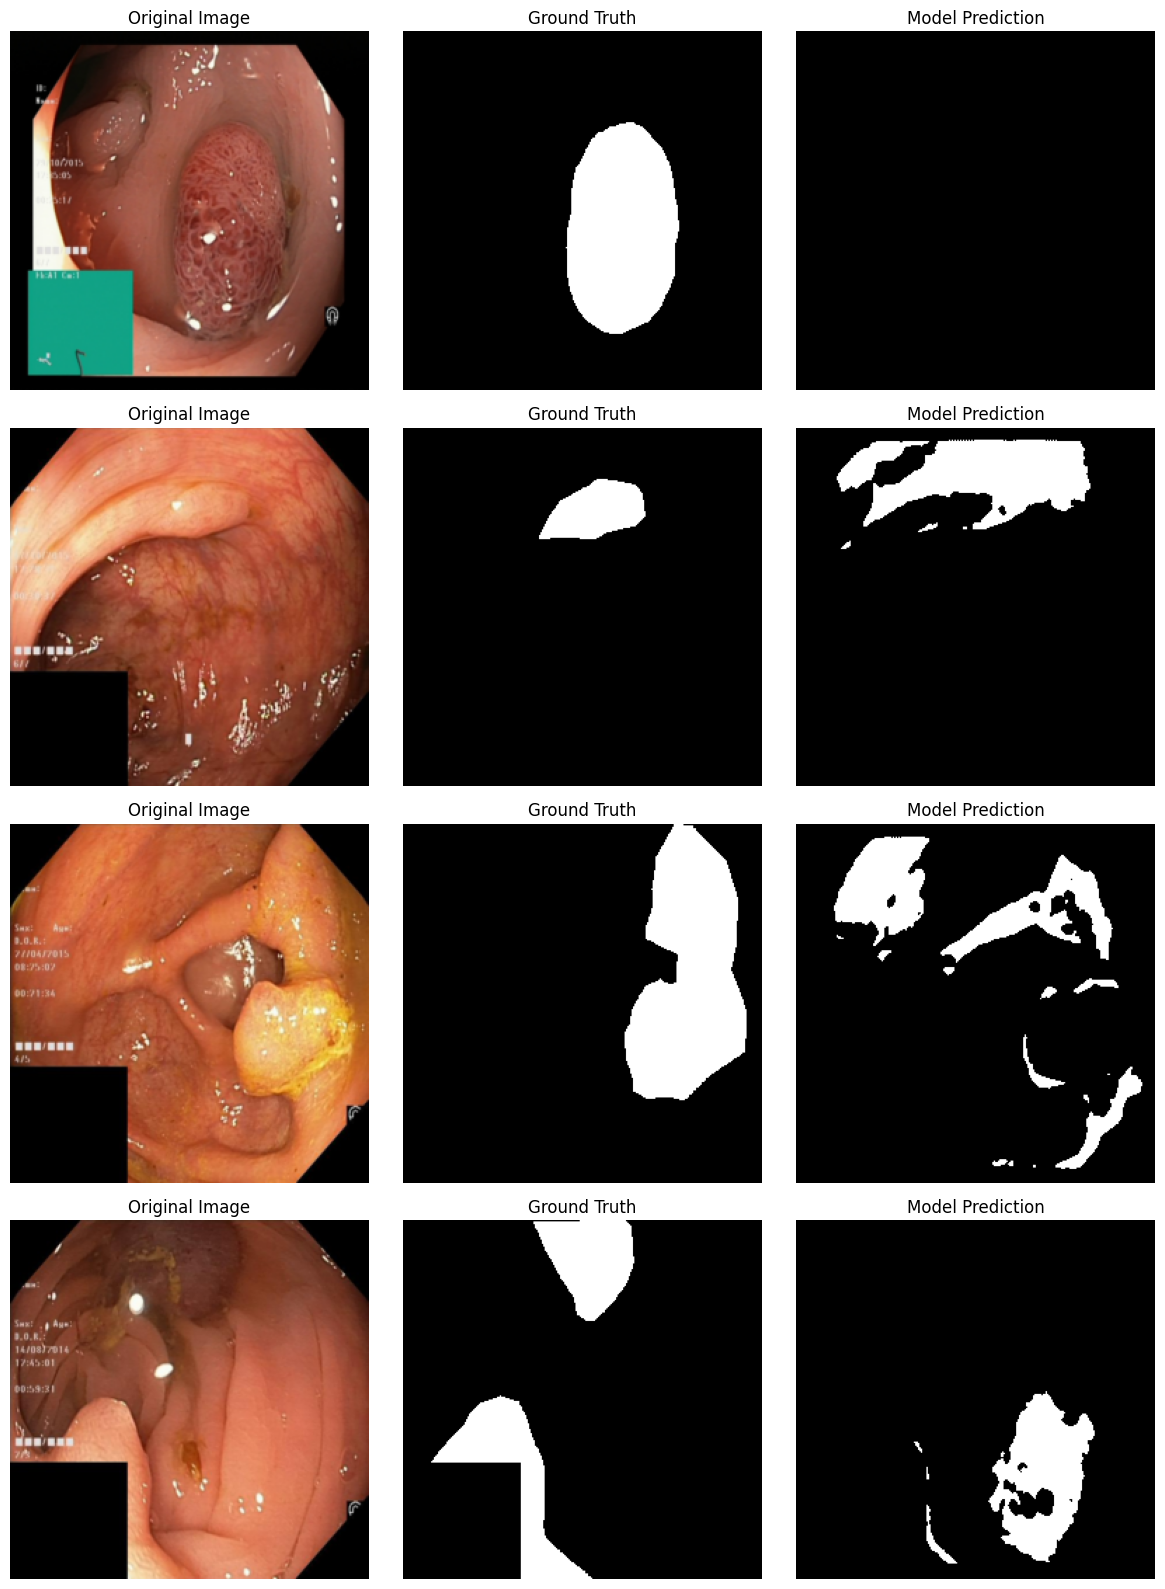

In [ ]:
import matplotlib.pyplot as plt

model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = model(images)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > 0.5).float()

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    image = images[i].cpu().permute(1, 2, 0).numpy()
    ground_truth = masks[i, 0].cpu().numpy()
    prediction = predictions[i, 0].cpu().numpy()

    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Original Image")

    axes[i, 1].imshow(ground_truth, cmap="gray")
    axes[i, 1].set_title("Ground Truth")

    axes[i, 2].imshow(prediction, cmap="gray")
    axes[i, 2].set_title("Model Prediction")

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import time
import copy

EPOCHS = 15

best_val_dice = -1.0
best_model_state = None

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

for epoch in range(1, EPOCHS + 1):

    start = time.time()

    train_loss, train_dice, train_iou = train_one_epoch(
        model, train_loader, optimizer, device
    )

    val_loss, val_dice, val_iou = validate(
        model, val_loader, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        best_model_state = copy.deepcopy(model.state_dict())

    elapsed = time.time() - start

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Dice {train_dice:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Dice {val_dice:.4f} | "
        f"Val IoU {val_iou:.4f} | "
        f"{elapsed:.1f}s"
    )

print("\nBest validation Dice:", best_val_dice)

Epoch 01/15 | Train Loss 1.1037 | Train Dice 0.3172 | Val Loss 1.1069 | Val Dice 0.3528 | Val IoU 0.2452 | 17.0s
Epoch 02/15 | Train Loss 1.0961 | Train Dice 0.2609 | Val Loss 1.0807 | Val Dice 0.3685 | Val IoU 0.2589 | 16.7s
Epoch 03/15 | Train Loss 1.0930 | Train Dice 0.3329 | Val Loss 1.0509 | Val Dice 0.3240 | Val IoU 0.2297 | 16.3s
Epoch 04/15 | Train Loss 1.0472 | Train Dice 0.4099 | Val Loss 1.1041 | Val Dice 0.2394 | Val IoU 0.1651 | 16.4s
Epoch 05/15 | Train Loss 1.0301 | Train Dice 0.4268 | Val Loss 1.0017 | Val Dice 0.4219 | Val IoU 0.3011 | 16.2s
Epoch 06/15 | Train Loss 0.9995 | Train Dice 0.4333 | Val Loss 1.0020 | Val Dice 0.4223 | Val IoU 0.3015 | 17.4s
Epoch 07/15 | Train Loss 0.9973 | Train Dice 0.4373 | Val Loss 1.0276 | Val Dice 0.4286 | Val IoU 0.3052 | 17.4s
Epoch 08/15 | Train Loss 0.9926 | Train Dice 0.4434 | Val Loss 0.9998 | Val Dice 0.4116 | Val IoU 0.2938 | 17.7s
Epoch 09/15 | Train Loss 0.9829 | Train Dice 0.4484 | Val Loss 0.9775 | Val Dice 0.4129 | Val Io

In [ ]:
model.load_state_dict(best_model_state)
model = model.to(device)

print(f"Restored best checkpoint")
print(f"Best validation Dice: {best_val_dice:.4f}")

Restored best checkpoint
Best validation Dice: 0.4545


In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/polypvision_unet_baseline.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_dice": best_val_dice,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
}, CHECKPOINT_PATH)

print("Saved:", CHECKPOINT_PATH)

Saved: /content/drive/MyDrive/polypvision_unet_baseline.pth


## 9. Interim held-out evaluation


In [ ]:
test_loss, test_dice, test_iou = validate(
    model,
    test_loader,
    device
)

print("=" * 40)
print("POLYPVISION AI — TEST RESULTS")
print("=" * 40)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f}")
print(f"Test IoU:  {test_iou:.4f}")
print("=" * 40)
print("Test images:", len(test_dataset))

POLYPVISION AI — TEST RESULTS
Test Loss: 0.9241
Test Dice: 0.5083
Test IoU:  0.3753
Test images: 150


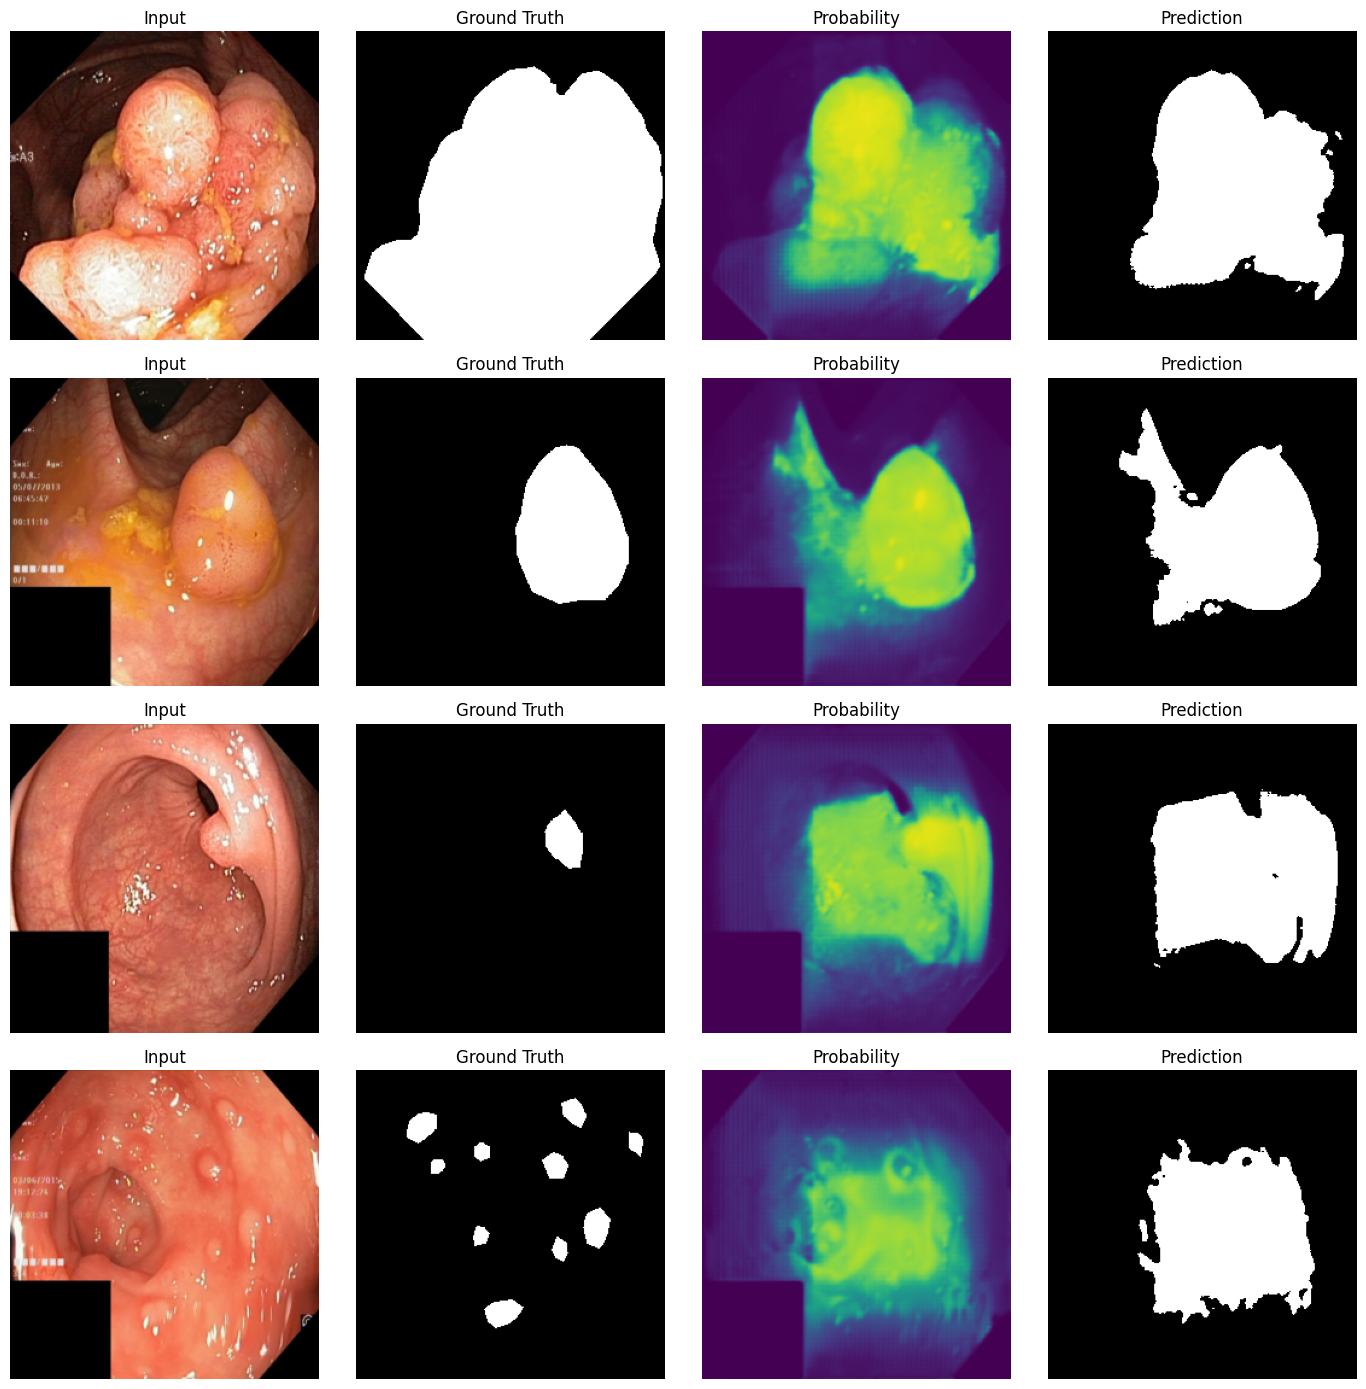

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

images, masks = next(iter(test_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = model(images)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > 0.5).float()

fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for i in range(4):
    image = images[i].cpu().permute(1, 2, 0).numpy()
    ground_truth = masks[i, 0].cpu().numpy()
    probability = probabilities[i, 0].cpu().numpy()
    prediction = predictions[i, 0].cpu().numpy()

    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Input")

    axes[i, 1].imshow(ground_truth, cmap="gray")
    axes[i, 1].set_title("Ground Truth")

    axes[i, 2].imshow(probability, cmap="viridis", vmin=0, vmax=1)
    axes[i, 2].set_title("Probability")

    axes[i, 3].imshow(prediction, cmap="gray", vmin=0, vmax=1)
    axes[i, 3].set_title("Prediction")

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/polypvision_test_predictions.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 10. Continued baseline optimization


In [ ]:
# Start from our BEST validation checkpoint
model.load_state_dict(best_model_state)
model = model.to(device)

# Smaller learning rate for fine-tuning
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

EPOCHS = 20
PATIENCE = 6

best_finetune_dice = best_val_dice
best_finetune_state = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):

    start = time.time()

    train_loss, train_dice, train_iou = train_one_epoch(
        model, train_loader, optimizer, device
    )

    val_loss, val_dice, val_iou = validate(
        model, val_loader, device
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Dice {train_dice:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Dice {val_dice:.4f} | "
        f"Val IoU {val_iou:.4f} | "
        f"{time.time()-start:.1f}s"
    )

    if val_dice > best_finetune_dice:
        best_finetune_dice = val_dice
        best_finetune_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        print("  -> New best checkpoint")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("\nEarly stopping.")
        break

print("\nBest fine-tuning validation Dice:",
      round(best_finetune_dice, 4))

Epoch 01/20 | Train Loss 0.9277 | Train Dice 0.4853 | Val Loss 0.9284 | Val Dice 0.4566 | Val IoU 0.3308 | 17.7s
  -> New best checkpoint
Epoch 02/20 | Train Loss 0.9160 | Train Dice 0.4951 | Val Loss 0.9239 | Val Dice 0.4521 | Val IoU 0.3292 | 16.7s
Epoch 03/20 | Train Loss 0.9089 | Train Dice 0.4978 | Val Loss 0.9198 | Val Dice 0.4662 | Val IoU 0.3393 | 16.2s
  -> New best checkpoint
Epoch 04/20 | Train Loss 0.9072 | Train Dice 0.5005 | Val Loss 0.9102 | Val Dice 0.4710 | Val IoU 0.3440 | 16.1s
  -> New best checkpoint
Epoch 05/20 | Train Loss 0.9008 | Train Dice 0.5022 | Val Loss 0.9093 | Val Dice 0.4714 | Val IoU 0.3450 | 16.5s
  -> New best checkpoint
Epoch 06/20 | Train Loss 0.8939 | Train Dice 0.5078 | Val Loss 0.9098 | Val Dice 0.4869 | Val IoU 0.3566 | 16.7s
  -> New best checkpoint
Epoch 07/20 | Train Loss 0.8899 | Train Dice 0.5104 | Val Loss 0.9052 | Val Dice 0.4567 | Val IoU 0.3381 | 16.6s
Epoch 08/20 | Train Loss 0.8754 | Train Dice 0.5192 | Val Loss 0.9060 | Val Dice 0.4

In [ ]:
model.load_state_dict(best_finetune_state)
model = model.to(device)

FINETUNE_PATH = "/content/drive/MyDrive/polypvision_unet_finetuned.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "best_val_dice": best_finetune_dice,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "learning_rate": 1e-4
}, FINETUNE_PATH)

print("Saved:", FINETUNE_PATH)
print(f"Best validation Dice: {best_finetune_dice:.4f}")

Saved: /content/drive/MyDrive/polypvision_unet_finetuned.pth
Best validation Dice: 0.5648


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

best_dice = best_finetune_dice
best_state = copy.deepcopy(model.state_dict())
no_improvement = 0

for epoch in range(21, 36):

    train_loss, train_dice, train_iou = train_one_epoch(
        model, train_loader, optimizer, device
    )

    val_loss, val_dice, val_iou = validate(
        model, val_loader, device
    )

    scheduler.step(val_dice)

    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d} | "
        f"Train Dice {train_dice:.4f} | "
        f"Val Dice {val_dice:.4f} | "
        f"Val IoU {val_iou:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"LR {lr:.1e}"
    )

    if val_dice > best_dice:
        best_dice = val_dice
        best_state = copy.deepcopy(model.state_dict())
        no_improvement = 0
        print("  -> New best checkpoint")
    else:
        no_improvement += 1

    if no_improvement >= 7:
        print("Early stopping.")
        break

print(f"\nBest validation Dice: {best_dice:.4f}")

Epoch 21 | Train Dice 0.6242 | Val Dice 0.5510 | Val IoU 0.4300 | Val Loss 0.7850 | LR 1.0e-04
Epoch 22 | Train Dice 0.6344 | Val Dice 0.5726 | Val IoU 0.4470 | Val Loss 0.7661 | LR 1.0e-04
  -> New best checkpoint
Epoch 23 | Train Dice 0.6400 | Val Dice 0.5887 | Val IoU 0.4590 | Val Loss 0.7568 | LR 1.0e-04
  -> New best checkpoint
Epoch 24 | Train Dice 0.6471 | Val Dice 0.5744 | Val IoU 0.4519 | Val Loss 0.7479 | LR 1.0e-04
Epoch 25 | Train Dice 0.6513 | Val Dice 0.5922 | Val IoU 0.4672 | Val Loss 0.7367 | LR 1.0e-04
  -> New best checkpoint
Epoch 26 | Train Dice 0.6640 | Val Dice 0.5810 | Val IoU 0.4524 | Val Loss 0.7666 | LR 1.0e-04
Epoch 27 | Train Dice 0.6646 | Val Dice 0.5938 | Val IoU 0.4702 | Val Loss 0.7284 | LR 1.0e-04
  -> New best checkpoint
Epoch 28 | Train Dice 0.6712 | Val Dice 0.5988 | Val IoU 0.4779 | Val Loss 0.7199 | LR 1.0e-04
  -> New best checkpoint
Epoch 29 | Train Dice 0.6888 | Val Dice 0.6037 | Val IoU 0.4783 | Val Loss 0.7378 | LR 1.0e-04
  -> New best checkp

In [ ]:
model.load_state_dict(best_state)
model = model.to(device)

FINAL_BASELINE_PATH = (
    "/content/drive/MyDrive/"
    "polypvision_unet_baseline_best.pth"
)

torch.save({
    "model_state_dict": model.state_dict(),
    "best_val_dice": best_dice,
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "architecture": "U-Net from scratch",
    "validation_dice": best_dice,
}, FINAL_BASELINE_PATH)

print("Checkpoint saved.")
print("Best validation Dice:", best_dice)
print("Path:", FINAL_BASELINE_PATH)

Checkpoint saved.
Best validation Dice: 0.6195031420180672
Path: /content/drive/MyDrive/polypvision_unet_baseline_best.pth


## 11. Augmentation ablation


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import random

IMAGE_SIZE = 256


class PairedAugmentation:
    def __init__(self, hflip_p=0.5, vflip_p=0.5):
        self.hflip_p = hflip_p
        self.vflip_p = vflip_p

    def __call__(self, image, mask):

        # Horizontal flip
        if random.random() < self.hflip_p:
            image = torch.flip(image, dims=[2])
            mask = torch.flip(mask, dims=[2])

        # Vertical flip
        if random.random() < self.vflip_p:
            image = torch.flip(image, dims=[1])
            mask = torch.flip(mask, dims=[1])

        return image, mask


class PolypDataset(Dataset):

    def __init__(self, indices, augmentation=None):
        self.ids = [valid_ids[i] for i in indices]
        self.augmentation = augmentation

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):

        sample_id = self.ids[idx]

        # Load
        image = Image.open(
            image_map[sample_id]
        ).convert("RGB")

        mask = Image.open(
            mask_map[sample_id]
        ).convert("L")

        # Resize
        image = image.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.BILINEAR
        )

        mask = mask.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            Image.Resampling.NEAREST
        )

        # Image -> float [0,1]
        image = np.array(
            image,
            dtype=np.float32
        ) / 255.0

        # Mask -> binary {0,1}
        mask = (
            np.array(mask) > 127
        ).astype(np.float32)

        # NumPy -> PyTorch
        image = torch.from_numpy(
            image
        ).permute(2, 0, 1)

        mask = torch.from_numpy(
            mask
        ).unsqueeze(0)

        # IMPORTANT:
        # transform image and mask TOGETHER
        if self.augmentation is not None:
            image, mask = self.augmentation(
                image,
                mask
            )

        return image, mask

In [ ]:
train_augmentation = PairedAugmentation(
    hflip_p=0.5,
    vflip_p=0.5
)

train_dataset_aug = PolypDataset(
    train_indices,
    augmentation=train_augmentation
)

val_dataset_clean = PolypDataset(
    val_indices,
    augmentation=None
)

print("Training:", len(train_dataset_aug))
print("Validation:", len(val_dataset_clean))

Training: 700
Validation: 150


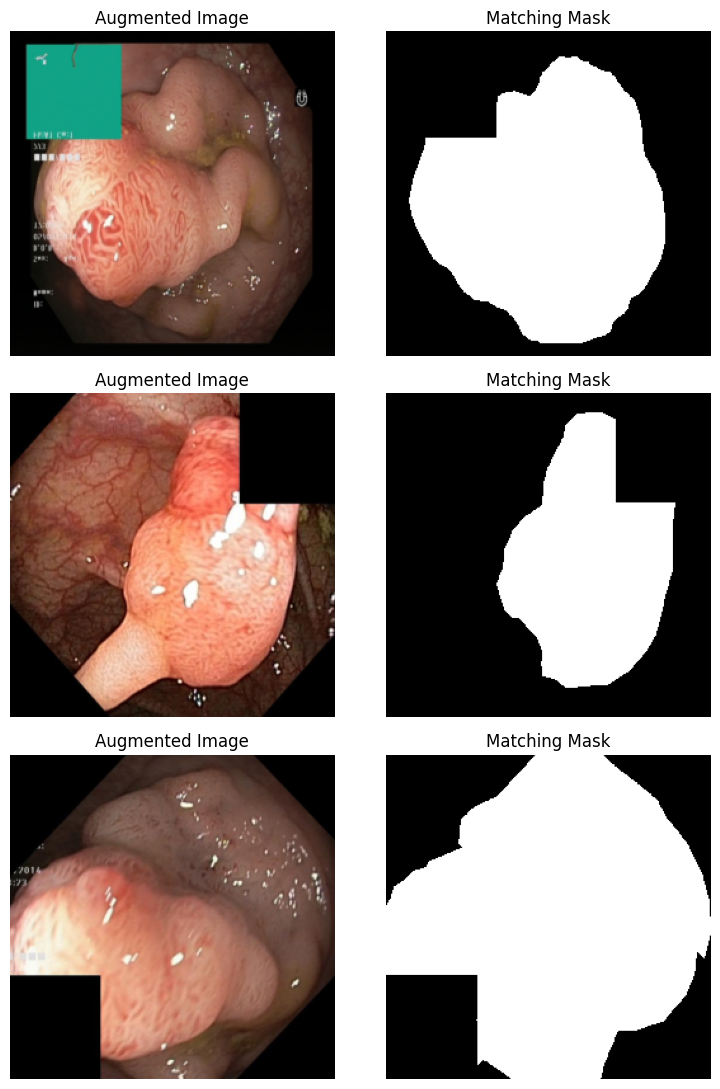

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(8, 11))

for i in range(3):
    image, mask = train_dataset_aug[i]

    axes[i, 0].imshow(image.permute(1, 2, 0))
    axes[i, 0].set_title("Augmented Image")

    axes[i, 1].imshow(mask[0], cmap="gray")
    axes[i, 1].set_title("Matching Mask")

    axes[i, 0].axis("off")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import DataLoader

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_clean = DataLoader(
    val_dataset_clean,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader_aug))
print("Validation batches:", len(val_loader_clean))

Training batches: 88
Validation batches: 19


In [ ]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Brand-new model with random weights
model_aug = PolypUNet().to(device)

optimizer_aug = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)

parameters = sum(
    p.numel()
    for p in model_aug.parameters()
    if p.requires_grad
)

print("Device:", device)
print("Model:", model_aug.__class__.__name__)
print("Trainable parameters:", f"{parameters:,}")
print("Learning rate:", optimizer_aug.param_groups[0]["lr"])

Device: cuda
Model: PolypUNet
Trainable parameters: 7,760,097
Learning rate: 0.001


In [ ]:
import copy
import time

scheduler_aug = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_aug,
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

best_aug_dice = -1.0
best_aug_state = None
epochs_without_improvement = 0

history_aug = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": []
}

MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10

for epoch in range(1, MAX_EPOCHS + 1):

    start = time.time()

    # TRAIN — augmented images
    train_loss, train_dice, train_iou = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer_aug,
        device
    )

    # VALIDATE — original, unaugmented images
    val_loss, val_dice, val_iou = validate(
        model_aug,
        val_loader_clean,
        device
    )

    scheduler_aug.step(val_dice)

    current_lr = optimizer_aug.param_groups[0]["lr"]

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["train_dice"].append(train_dice)
    history_aug["val_dice"].append(val_dice)
    history_aug["train_iou"].append(train_iou)
    history_aug["val_iou"].append(val_iou)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Dice {train_dice:.4f} | "
        f"Val Dice {val_dice:.4f} | "
        f"Val IoU {val_iou:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"LR {current_lr:.1e} | "
        f"{time.time() - start:.1f}s"
    )

    # Save best validation model
    if val_dice > best_aug_dice:

        best_aug_dice = val_dice
        best_aug_state = copy.deepcopy(
            model_aug.state_dict()
        )

        epochs_without_improvement = 0

        print("  -> NEW BEST")

    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping triggered.")
        break


print("\n" + "=" * 45)
print("EXPERIMENT 2 COMPLETE")
print("=" * 45)
print(f"Best Augmentation Val Dice: {best_aug_dice:.4f}")
print(f"Experiment 1 Val Dice:      0.6195")

Epoch 01/50 | Train Dice 0.0030 | Val Dice 0.0000 | Val IoU 0.0000 | Val Loss 1.1010 | LR 1.0e-03 | 17.1s
  -> NEW BEST
Epoch 02/50 | Train Dice 0.2728 | Val Dice 0.3269 | Val IoU 0.2256 | Val Loss 1.0971 | LR 1.0e-03 | 16.8s
  -> NEW BEST
Epoch 03/50 | Train Dice 0.2959 | Val Dice 0.0505 | Val IoU 0.0300 | Val Loss 1.1377 | LR 1.0e-03 | 16.4s
Epoch 04/50 | Train Dice 0.3267 | Val Dice 0.3428 | Val IoU 0.2373 | Val Loss 1.1089 | LR 1.0e-03 | 16.4s
  -> NEW BEST
Epoch 05/50 | Train Dice 0.3407 | Val Dice 0.2319 | Val IoU 0.1559 | Val Loss 1.0962 | LR 1.0e-03 | 16.3s
Epoch 06/50 | Train Dice 0.3097 | Val Dice 0.3209 | Val IoU 0.2231 | Val Loss 1.0929 | LR 1.0e-03 | 16.4s
Epoch 07/50 | Train Dice 0.3379 | Val Dice 0.3485 | Val IoU 0.2414 | Val Loss 1.1075 | LR 1.0e-03 | 17.1s
  -> NEW BEST
Epoch 08/50 | Train Dice 0.3245 | Val Dice 0.3020 | Val IoU 0.2087 | Val Loss 1.0927 | LR 1.0e-03 | 16.4s
Epoch 09/50 | Train Dice 0.3241 | Val Dice 0.3680 | Val IoU 0.2539 | Val Loss 1.1286 | LR 1.0e-0

## 12. Selected checkpoint and inference


In [ ]:
import os

BASELINE_PATH = (
    "/content/drive/MyDrive/"
    "polypvision_unet_baseline_best.pth"
)

print("Exists:", os.path.exists(BASELINE_PATH))
print("Path:", BASELINE_PATH)

Exists: True
Path: /content/drive/MyDrive/polypvision_unet_baseline_best.pth


In [ ]:
BASELINE_PATH = (
    "/content/drive/MyDrive/"
    "polypvision_unet_baseline_best.pth"
)

checkpoint = torch.load(
    BASELINE_PATH,
    map_location=device
)

inference_model = PolypUNet().to(device)

inference_model.load_state_dict(
    checkpoint["model_state_dict"]
)

inference_model.eval()

print("Model loaded successfully")
print("Validation Dice:", checkpoint["best_val_dice"])
print("Device:", device)

Model loaded successfully
Validation Dice: 0.6195031420180672
Device: cuda


In [ ]:
from PIL import Image
import numpy as np
import torch

def predict_polyp(model, image_path, threshold=0.5):

    # Keep original for visualization
    original = Image.open(image_path).convert("RGB")

    # Same preprocessing used during training
    resized = original.resize(
        (256, 256),
        Image.Resampling.BILINEAR
    )

    image_np = np.array(
        resized,
        dtype=np.float32
    ) / 255.0

    tensor = torch.from_numpy(
        image_np
    ).permute(2, 0, 1).unsqueeze(0)

    tensor = tensor.to(device)

    # Inference
    with torch.no_grad():
        logits = model(tensor)
        probability = torch.sigmoid(logits)

    probability = probability[
        0, 0
    ].cpu().numpy()

    mask = (
        probability >= threshold
    ).astype(np.uint8)

    return original, probability, mask

In [ ]:
# Pick one image from the held-out test split
sample_id = valid_ids[test_indices[0]]
unseen_path = image_map[sample_id]

original, probability, prediction = predict_polyp(
    inference_model,
    unseen_path,
    threshold=0.5
)

print("Image:", sample_id)
print("Probability range:",
      probability.min(),
      probability.max())

print(
    "Predicted polyp area:",
    f"{prediction.mean() * 100:.2f}%"
)

Image: cju17otoe119u0799nqcbl8n1
Probability range: 4.6256594e-07 0.99997056
Predicted polyp area: 24.35%


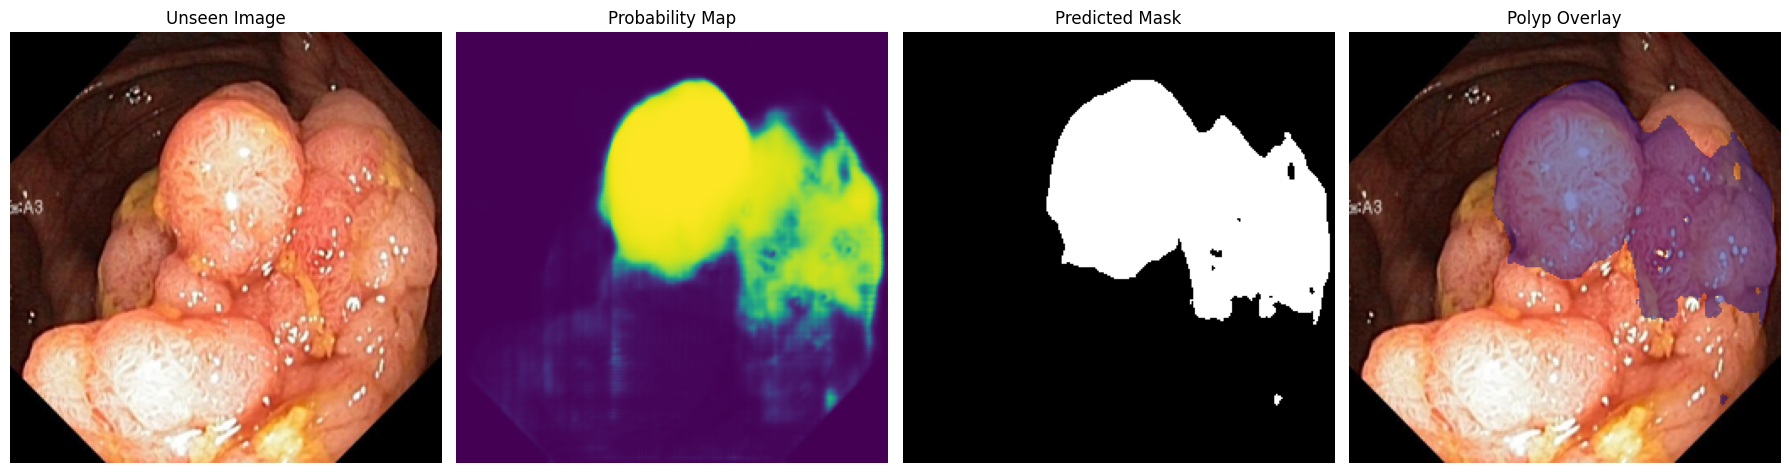

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Resize original for matching visualization
display_image = np.array(
    original.resize((256, 256))
)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Original
axes[0].imshow(display_image)
axes[0].set_title("Unseen Image")

# Probability map
axes[1].imshow(
    probability,
    cmap="viridis",
    vmin=0,
    vmax=1
)
axes[1].set_title("Probability Map")

# Binary prediction
axes[2].imshow(
    prediction,
    cmap="gray",
    vmin=0,
    vmax=1
)
axes[2].set_title("Predicted Mask")

# Overlay
axes[3].imshow(display_image)

axes[3].imshow(
    np.ma.masked_where(
        prediction == 0,
        prediction
    ),
    cmap="jet",
    alpha=0.45
)

axes[3].set_title("Polyp Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()